In [3]:
import subprocess
subprocess.run(["pip", "install", "textblob", "yfinance", "requests", "nltk"])

CompletedProcess(args=['pip', 'install', 'textblob', 'yfinance', 'requests', 'nltk'], returncode=0)

In [5]:
import pandas as pd
import yfinance as yf
import requests
from textblob import TextBlob
import nltk
nltk.download('punkt')
nltk.download('stopwords')
print("All libraries loaded ✅")

All libraries loaded ✅


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sanch\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
API_KEY = "71e41920ec6e4fc694142be4b3bf7d9a"
url = f"https://newsapi.org/v2/everything?q=stock+market+india+nifty&language=en&pageSize=50&apiKey={API_KEY}"
response = requests.get(url)
data = response.json()
# Extract headlines and dates
articles = data["articles"]
headlines = []
for article in articles:
    headlines.append({
        "date": article["publishedAt"][:10],
        "headline": article["title"],
        "source": article["source"]["name"]
    })

df = pd.DataFrame(headlines)
print(f"✅ Fetched {len(df)} headlines")
df.head(10)

✅ Fetched 50 headlines


,date,headline,source
0,2026-05-20,Eurobank enables Greece-India UPI remittances,The Times of India
1,2026-05-18,"Rupee hits new low of 96.4, falls for 7th stra...",The Indian Express
2,2026-06-08,Indian stocks and rupee fall on global selloff...,The Indian Express
3,2026-06-10,War impact: Investors turned cautious in May a...,The Indian Express
4,2026-06-07,NSE investor accounts cross 26 crore milestone...,The Times of India
5,2026-06-08,Indian stock markets dive amid Middle East esc...,DW (English)
6,2026-05-16,Quant Mid Cap Fund exits Lenskart Solutions an...,Economictimes.com
7,2026-05-25,"Bitcoin trades above $77,000 as oil's 5% slide...",CoinDesk
8,2026-05-20,Sensex today | Stock Market Highlights: Stock ...,BusinessLine
9,2026-05-26,India's fifth spot in global market cap list u...,Japan Today


In [10]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0.1:
        return "Positive", score
    elif score < -0.1:
        return "Negative", score
    else:
        return "Neutral", score

# Apply to every headline
df["sentiment"], df["score"] = zip(*df["headline"].apply(get_sentiment))

print("✅ Sentiment scoring done!")
print(df["sentiment"].value_counts())
df.head(10)

✅ Sentiment scoring done!
sentiment
Neutral     25
Positive    19
Negative     6
Name: count, dtype: int64


,date,headline,source,sentiment,score
0,2026-05-20,Eurobank enables Greece-India UPI remittances,The Times of India,Neutral,0.000000
1,2026-05-18,"Rupee hits new low of 96.4, falls for 7th stra...",The Indian Express,Positive,0.112121
2,2026-06-08,Indian stocks and rupee fall on global selloff...,The Indian Express,Neutral,0.000000
3,2026-06-10,War impact: Investors turned cautious in May a...,The Indian Express,Neutral,0.000000
4,2026-06-07,NSE investor accounts cross 26 crore milestone...,The Times of India,Neutral,0.000000
5,2026-06-08,Indian stock markets dive amid Middle East esc...,DW (English),Neutral,0.000000
6,2026-05-16,Quant Mid Cap Fund exits Lenskart Solutions an...,Economictimes.com,Neutral,-0.062500
7,2026-05-25,"Bitcoin trades above $77,000 as oil's 5% slide...",CoinDesk,Neutral,0.083333
8,2026-05-20,Sensex today | Stock Market Highlights: Stock ...,BusinessLine,Neutral,0.000000
9,2026-05-26,India's fifth spot in global market cap list u...,Japan Today,Neutral,0.000000


In [11]:
import yfinance as yf

# Download Nifty 50 index data
nifty = yf.download("^NSEI", start="2026-05-01", end="2026-06-14")

# Calculate daily % change
nifty["daily_change"] = nifty["Close"].pct_change() * 100
nifty["date"] = nifty.index.astype(str)

# Keep only date and change
nifty_df = nifty[["date", "daily_change"]].reset_index(drop=True)

print("✅ Nifty data fetched!")
nifty_df.head(10)

[*********************100%***********************]  1 of 1 completed

✅ Nifty data fetched!


Price,date,daily_change
Ticker,,
0,2026-05-04,NaN
1,2026-05-05,-0.358634
2,2026-05-06,1.240590
3,2026-05-07,-0.017668
4,2026-05-08,-0.618663
5,2026-05-11,-1.490315
6,2026-05-12,-1.831968
7,2026-05-13,0.141358
8,2026-05-14,1.183124


In [14]:
# Fix yfinance multi-level columns issue
nifty = yf.download("^NSEI", start="2026-05-01", end="2026-06-14")
nifty.columns = nifty.columns.get_level_values(0)  # flatten columns

# Calculate daily % change
nifty["daily_change"] = nifty["Close"].pct_change() * 100
nifty["date"] = nifty.index.strftime("%Y-%m-%d")

nifty_df = nifty[["date", "daily_change"]].reset_index(drop=True)

# Group sentiment by date
daily_sentiment = df.groupby("date")["score"].mean().reset_index()
daily_sentiment.columns = ["date", "avg_sentiment"]

# Merge
merged = pd.merge(daily_sentiment, nifty_df, on="date", how="inner")
print(f"✅ Merged! {len(merged)} matching days found")
merged

[*********************100%***********************]  1 of 1 completed

✅ Merged! 19 matching days found


,date,avg_sentiment,daily_change
0,2026-05-13,-0.450000,0.141358
1,2026-05-15,0.100000,-0.194599
2,2026-05-18,0.133424,0.027277
3,2026-05-19,0.212121,-0.135092
4,2026-05-20,0.075000,0.173596
5,2026-05-21,0.300000,-0.018178
6,2026-05-22,0.068182,0.273102
7,2026-05-25,0.077778,1.317064
8,2026-05-26,0.150000,-0.491018
9,2026-05-27,0.500000,-0.027385


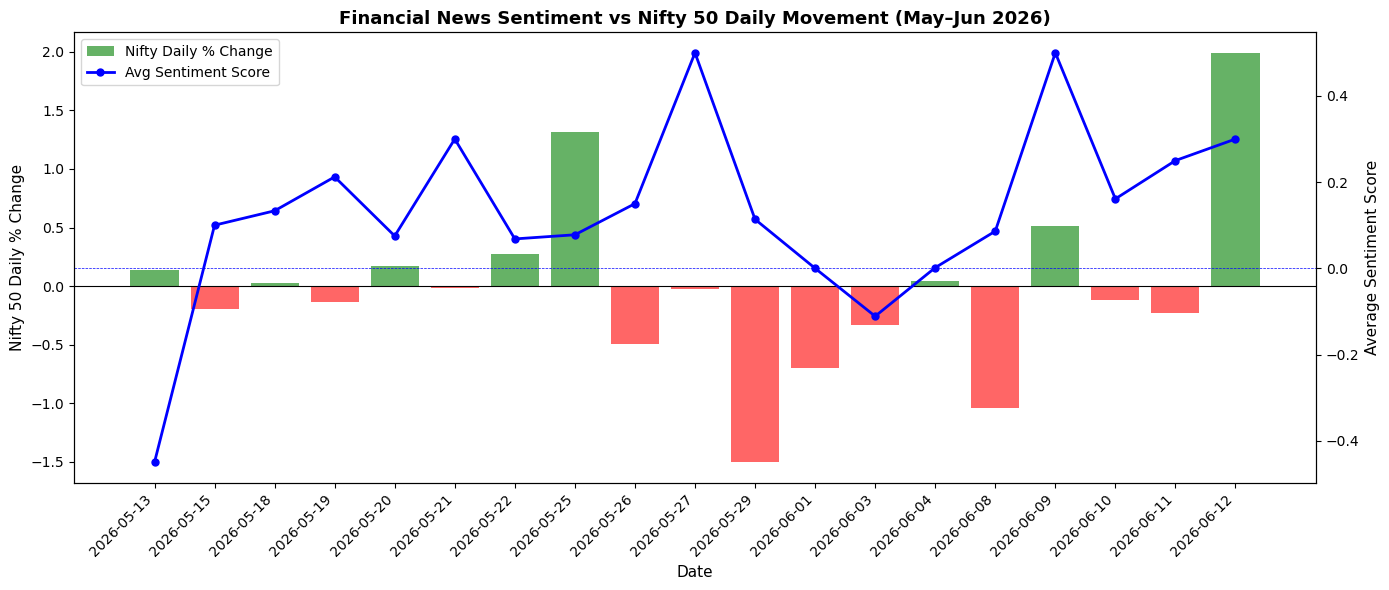

✅ Chart saved!


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart — Nifty daily change
colors_bar = ["red" if x < 0 else "green" for x in merged["daily_change"]]
ax1.bar(merged["date"], merged["daily_change"], color=colors_bar, alpha=0.6, label="Nifty Daily % Change")
ax1.set_ylabel("Nifty 50 Daily % Change", fontsize=11)
ax1.set_xlabel("Date", fontsize=11)
ax1.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")

# Line chart — Sentiment score (second axis)
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["avg_sentiment"], color="blue", marker="o",
         linewidth=2, markersize=5, label="Avg Sentiment Score")
ax2.set_ylabel("Average Sentiment Score", fontsize=11)
ax2.axhline(0, color="blue", linewidth=0.5, linestyle="--")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Financial News Sentiment vs Nifty 50 Daily Movement (May–Jun 2026)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sentiment_vs_nifty.png", dpi=150)
plt.show()
print("✅ Chart saved!")

In [16]:
merged.to_csv("sentiment_nifty_analysis.csv", index=False)
df.to_csv("headlines_sentiment.csv", index=False)
print("✅ Data saved to CSV!")

✅ Data saved to CSV!
